# Laboratorio 2 - Generadores de numeros aleatorios



## Librerias y parametros globales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

CANTIDAD_NUMEROS = 1000      # n de cada secuencia a evaluar
NIVEL_SIGNIFICANCIA = 0.05   # alpha
NUMERO_CLASES = 10           # k para chi-cuadrado
LIMITE_BUSQUEDA_CICLO = 300000

SECUENCIAS = []


def registrar_secuencia(metodo, nombre, uniformes, estados_para_ciclo):
    SECUENCIAS.append({
        "metodo": metodo,
        "nombre": nombre,
        "uniformes": uniformes,
        "estados": estados_para_ciclo,
    })


def mostrar_muestra(uniformes, cantidad=8):
    recorte = uniformes[:cantidad]
    return ", ".join(f"{u:.4f}" for u in recorte) + " ..."


# 5.1.1 Metodo de middle-square


In [2]:
def obtener_digitos_centrales(numero, cantidad_digitos):
    cuadrado = numero * numero
    cuadrado_texto = str(cuadrado).zfill(cantidad_digitos * 2)

    inicio = (len(cuadrado_texto) - cantidad_digitos) // 2
    fin = inicio + cantidad_digitos
    centrales = cuadrado_texto[inicio:fin]

    return int(centrales)


def middle_square(semilla, cantidad_digitos, cantidad):
    actual = semilla
    enteros = []

    for _ in range(cantidad):
        actual = obtener_digitos_centrales(actual, cantidad_digitos)
        enteros.append(actual)

    return enteros


def normalizar(enteros, cantidad_digitos):
    divisor = 10 ** cantidad_digitos
    uniformes = []

    for entero in enteros:
        uniformes.append(entero / divisor)

    return uniformes


semillas_ms = [1931, 675248, 4567, 12122, 7179345]

for semilla in semillas_ms:
    digitos = len(str(semilla))

    enteros = middle_square(semilla, digitos, CANTIDAD_NUMEROS)
    uniformes = normalizar(enteros, digitos)


    largo_ciclo = min(LIMITE_BUSQUEDA_CICLO, 10 ** digitos + 5)
    estados = middle_square(semilla, digitos, largo_ciclo)

    registrar_secuencia("middle-square", f"semilla={semilla}", uniformes, estados)
    print(f"semilla={semilla:>8} | {mostrar_muestra(uniformes)}")


semilla=    1931 | 0.7287, 0.1003, 0.0060, 0.0036, 0.0012, 0.0001, 0.0000, 0.0000 ...
semilla=  675248 | 0.9599, 0.3331, 0.9816, 0.5248, 0.4329, 0.3877, 0.3043, 0.6052 ...
semilla=    4567 | 0.8574, 0.5134, 0.3579, 0.8092, 0.4804, 0.0784, 0.6146, 0.7733 ...
semilla=   12122 | 0.4694, 0.0355, 0.1261, 0.5899, 0.7935, 0.9610, 0.3617, 0.0834 ...
semilla= 7179345 | 0.4299, 0.8537, 0.8631, 0.9566, 0.1371, 0.8047, 0.5728, 0.1341 ...


# 5.1.2 Generador congruencial mixto

$$X_{n+1} = (a X_n + c) \bmod m$$

In [3]:
def congruencial_mixto(semilla, multiplicador, incremento, modulo, cantidad):
    actual = semilla
    enteros = []
    uniformes = []

    for _ in range(cantidad):
        actual = (multiplicador * actual + incremento) % modulo
        enteros.append(actual)
        uniformes.append(actual / modulo)

    return enteros, uniformes


def maximo_comun_divisor(a, b):
    while b != 0:
        a, b = b, a % b
    return a


def factores_primos(numero):
    factores = set()
    divisor = 2

    while divisor * divisor <= numero:
        while numero % divisor == 0:
            factores.add(divisor)
            numero = numero // divisor
        divisor = divisor + 1

    if numero > 1:
        factores.add(numero)

    return factores


def cumple_hull_dobell(multiplicador, incremento, modulo):
    """Si se cumple, el periodo del generador mixto es exactamente m."""
    if incremento == 0:
        return False

    if maximo_comun_divisor(incremento, modulo) != 1:
        return False

    for primo in factores_primos(modulo):
        if (multiplicador - 1) % primo != 0:
            return False

    if modulo % 4 == 0 and (multiplicador - 1) % 4 != 0:
        return False

    return True


#         X0,        a,             c,   m
items = [
    [123,      115,           0,   128],
    [43,       25,            5,   48],
    [13,       16807,         0,   2**31 - 1],
    [29022024, 25214903917,   11,  2**48],
    [3,        5,             7,   200],
]

for semilla, multiplicador, incremento, modulo in items:
    _, uniformes = congruencial_mixto(
        semilla, multiplicador, incremento, modulo, CANTIDAD_NUMEROS
    )

    largo_ciclo = min(LIMITE_BUSQUEDA_CICLO, modulo + 5)
    estados, _ = congruencial_mixto(
        semilla, multiplicador, incremento, modulo, largo_ciclo
    )

    nombre = f"a={multiplicador} c={incremento} m={modulo}"
    registrar_secuencia("congruencial mixto", nombre, uniformes, estados)

    hull = cumple_hull_dobell(multiplicador, incremento, modulo)
    print(f"{nombre}")
    print(f"   Hull-Dobell (periodo = m): {hull}")
    print(f"   {mostrar_muestra(uniformes)}\n")


a=115 c=0 m=128
   Hull-Dobell (periodo = m): False
   0.5078, 0.3984, 0.8203, 0.3359, 0.6328, 0.7734, 0.9453, 0.7109 ...

a=25 c=5 m=48
   Hull-Dobell (periodo = m): True
   0.5000, 0.6042, 0.2083, 0.3125, 0.9167, 0.0208, 0.6250, 0.7292 ...

a=16807 c=0 m=2147483647
   Hull-Dobell (periodo = m): False
   0.0001, 0.7100, 0.8229, 0.9625, 0.9260, 0.8465, 0.6116, 0.8252 ...

a=25214903917 c=11 m=281474976710656
   Hull-Dobell (periodo = m): True
   0.8316, 0.5264, 0.5038, 0.0123, 0.9113, 0.9395, 0.0396, 0.2413 ...

a=5 c=7 m=200
   Hull-Dobell (periodo = m): False
   0.1100, 0.5850, 0.9600, 0.8350, 0.2100, 0.0850, 0.4600, 0.3350 ...



# 5.1.3 Otros generadores de numeros aleatorios

## Shift-Register


In [4]:
def generar_bits(semilla_bits, r, q, cantidad_bits):
    bits = list(semilla_bits)

    while len(bits) < cantidad_bits:
        bit_lejano = bits[len(bits) - r]
        bit_cercano = bits[len(bits) - q]
        nuevo_bit = bit_lejano ^ bit_cercano
        bits.append(nuevo_bit)

    return bits


def agrupar_bits_en_numeros(bits, longitud_palabra):
    numeros = []
    uniformes = []
    divisor = 2 ** longitud_palabra

    for inicio in range(0, len(bits) - longitud_palabra + 1, longitud_palabra):
        bloque = bits[inicio:inicio + longitud_palabra]

        valor = 0
        for bit in bloque:
            valor = valor * 2 + bit

        numeros.append(valor)
        uniformes.append(valor / divisor)

    return numeros, uniformes


def ventanas_de_estado(bits, r):
    """El estado del LFSR son los ultimos r bits. Sirve para detectar el ciclo."""
    ventanas = []

    for inicio in range(len(bits) - r + 1):
        ventanas.append(tuple(bits[inicio:inicio + r]))

    return ventanas


def construir_semilla_bits(r):
    patron = [1, 0, 0, 1, 0, 1, 1]
    repeticiones = (r // len(patron)) + 1
    return (patron * repeticiones)[:r]



configuraciones_sr = [
    [7,  3,  8],
    [31, 3,  8],
    [31, 13, 16],
]

for r, q, longitud_palabra in configuraciones_sr:
    semilla_bits = construir_semilla_bits(r)

    bits_salida = generar_bits(semilla_bits, r, q, longitud_palabra * CANTIDAD_NUMEROS)
    _, uniformes = agrupar_bits_en_numeros(bits_salida, longitud_palabra)


    bits_necesarios = min(LIMITE_BUSQUEDA_CICLO, 2 ** min(r, 20) + r + 10)
    bits_ciclo = generar_bits(semilla_bits, r, q, bits_necesarios)
    estados = ventanas_de_estado(bits_ciclo, r)

    nombre = f"r={r} q={q} L={longitud_palabra}"
    registrar_secuencia("shift-register", nombre, uniformes, estados)
    print(f"{nombre:<18} | {mostrar_muestra(uniformes)}")


r=7 q=3 L=8        | 0.5898, 0.8320, 0.0430, 0.4727, 0.7891, 0.7969, 0.1055, 0.3633 ...
r=31 q=3 L=8       | 0.5898, 0.1797, 0.3594, 0.7188, 0.1680, 0.2305, 0.7539, 0.3555 ...
r=31 q=13 L=16     | 0.5905, 0.3622, 0.7952, 0.8980, 0.7188, 0.0460, 0.1808, 0.3978 ...


## Congruencia inversa (ICG)


In [5]:
def es_primo(numero):
    if numero < 2:
        return False

    divisor = 2
    while divisor * divisor <= numero:
        if numero % divisor == 0:
            return False
        divisor = divisor + 1

    return True


def inverso_multiplicativo(numero, modulo):
    if numero % modulo == 0:
        return 0

    return pow(numero, modulo - 2, modulo)


def congruencia_inversa(semilla, multiplicador, incremento, modulo, cantidad):
    if not es_primo(modulo):
        raise ValueError("El modulo debe ser primo para el generador inverso")

    actual = semilla
    enteros = []
    uniformes = []

    for _ in range(cantidad):
        inverso = inverso_multiplicativo(actual, modulo)
        actual = (multiplicador * inverso + incremento) % modulo
        enteros.append(actual)
        uniformes.append(actual / modulo)

    return enteros, uniformes


#                X0, a, c,  m (primo)
configuraciones_icg = [
    [1, 2, 3,  31],
    [7, 5, 11, 101],
    [1, 2, 3,  2147483053],
]

for semilla, multiplicador, incremento, modulo in configuraciones_icg:
    _, uniformes = congruencia_inversa(
        semilla, multiplicador, incremento, modulo, CANTIDAD_NUMEROS
    )

    largo_ciclo = min(LIMITE_BUSQUEDA_CICLO, modulo + 5)
    estados, _ = congruencia_inversa(
        semilla, multiplicador, incremento, modulo, largo_ciclo
    )

    nombre = f"a={multiplicador} c={incremento} m={modulo}"
    registrar_secuencia("congruencia inversa", nombre, uniformes, estados)
    print(f"{nombre:<26} | {mostrar_muestra(uniformes)}")


a=2 c=3 m=31               | 0.1613, 0.7097, 0.6452, 0.0000, 0.0968, 0.4516, 0.3871, 0.9355 ...
a=5 c=11 m=101             | 0.5446, 0.5644, 0.0396, 0.8713, 0.6436, 0.8020, 0.3564, 0.4158 ...
a=2 c=3 m=2147483053       | 0.0000, 0.2000, 0.8235, 0.8033, 0.7834, 0.5408, 0.8987, 0.9712 ...


# 5.2 Pruebas aplicadas a cada secuencia

## a. Tamano de ciclo o periodo



In [6]:
def detectar_ciclo(estados):
    posicion_de_estado = {}

    for indice, estado in enumerate(estados):
        if estado in posicion_de_estado:
            inicio_del_ciclo = posicion_de_estado[estado]
            transitorio = inicio_del_ciclo
            periodo = indice - inicio_del_ciclo
            return transitorio, periodo

        posicion_de_estado[estado] = indice

    return None, None


def describir_ciclo(estados):
    transitorio, periodo = detectar_ciclo(estados)

    if periodo is None:
        return f"> {len(estados)}", None

    return f"{periodo} (transitorio {transitorio})", periodo


## b. Prueba de uniformidad: chi-cuadrado

In [7]:
def prueba_chi_cuadrado(uniformes, numero_clases, alpha):
    n = len(uniformes)

    frecuencia_observada, _ = np.histogram(uniformes, bins=numero_clases, range=(0, 1))
    frecuencia_esperada = n / numero_clases

    diferencias = (frecuencia_observada - frecuencia_esperada) ** 2
    estadistico = float(np.sum(diferencias / frecuencia_esperada))

    grados_libertad = numero_clases - 1
    valor_critico = float(stats.chi2.ppf(1 - alpha, grados_libertad))
    p_valor = float(1 - stats.chi2.cdf(estadistico, grados_libertad))

    se_acepta = estadistico <= valor_critico

    return {
        "estadistico": estadistico,
        "critico": valor_critico,
        "p_valor": p_valor,
        "acepta": se_acepta,
        "frecuencias": frecuencia_observada,
    }


## c. Prueba de aleatoriedad: test de rachas


In [8]:
def construir_sucesion_binaria(uniformes):
    n = len(uniformes)
    binaria = np.zeros(n - 1, dtype=int)

    for i in range(1, n):
        if uniformes[i - 1] > uniformes[i]:
            binaria[i - 1] = 0
        else:
            binaria[i - 1] = 1

    return binaria


def contar_rachas(binaria):
    como_booleano = (binaria == 1)

    hubo_cambio = como_booleano[:-1] ^ como_booleano[1:]
    posiciones_cambio = list(np.arange(len(hubo_cambio))[hubo_cambio])
    posiciones_cambio.insert(0, -1)
    posiciones_cambio = np.array(posiciones_cambio)

    longitudes = posiciones_cambio[1:] - posiciones_cambio[:-1]

    return len(longitudes), longitudes


def prueba_rachas(uniformes, alpha):
    n = len(uniformes)

    binaria = construir_sucesion_binaria(uniformes)
    numero_rachas, longitudes = contar_rachas(binaria)

    media = (2 * n - 1) / 3
    varianza = (16 * n - 29) / 90
    estadistico = (numero_rachas - media) / np.sqrt(varianza)

    valor_critico = float(stats.norm.ppf(1 - alpha / 2))
    se_acepta = abs(estadistico) <= valor_critico

    return {
        "rachas": numero_rachas,
        "estadistico": float(estadistico),
        "critico": valor_critico,
        "acepta": se_acepta,
        "longitudes": longitudes,
    }


# 5.3 Resultados

Se corren las tres pruebas sobre cada una de las secuencias registradas.

In [9]:
resultados = []

for secuencia in SECUENCIAS:
    texto_ciclo, periodo = describir_ciclo(secuencia["estados"])
    chi = prueba_chi_cuadrado(secuencia["uniformes"], NUMERO_CLASES, NIVEL_SIGNIFICANCIA)
    rachas = prueba_rachas(secuencia["uniformes"], NIVEL_SIGNIFICANCIA)

    resultados.append({
        "metodo": secuencia["metodo"],
        "nombre": secuencia["nombre"],
        "ciclo": texto_ciclo,
        "periodo": periodo,
        "valores_distintos": len(set(secuencia["uniformes"])),
        "chi": chi,
        "rachas": rachas,
    })


def imprimir_tabla(resultados):
    encabezado = (
        f"{'METODO':<20} {'PARAMETROS':<30} {'PERIODO':<22} "
        f"{'CHI2':>10} {'UNIF':<6} {'R':>6} {'Z':>9} {'ALEAT':<6}"
    )
    print(encabezado)
    print("-" * len(encabezado))

    for fila in resultados:
        veredicto_unif = "PASA" if fila["chi"]["acepta"] else "FALLA"
        veredicto_aleat = "PASA" if fila["rachas"]["acepta"] else "FALLA"

        print(
            f"{fila['metodo']:<20} {fila['nombre']:<30} {fila['ciclo']:<22} "
            f"{fila['chi']['estadistico']:>10.2f} {veredicto_unif:<6} "
            f"{fila['rachas']['rachas']:>6} {fila['rachas']['estadistico']:>9.3f} "
            f"{veredicto_aleat:<6}"
        )


print(f"n = {CANTIDAD_NUMEROS} | alpha = {NIVEL_SIGNIFICANCIA} | k = {NUMERO_CLASES}")
print(f"chi2 critico = {stats.chi2.ppf(1 - NIVEL_SIGNIFICANCIA, NUMERO_CLASES - 1):.2f} | "
      f"Z critico = {stats.norm.ppf(1 - NIVEL_SIGNIFICANCIA / 2):.3f}\n")

imprimir_tabla(resultados)


n = 1000 | alpha = 0.05 | k = 10
chi2 critico = 16.92 | Z critico = 1.960

METODO               PARAMETROS                     PERIODO                      CHI2 UNIF        R         Z ALEAT 
--------------------------------------------------------------------------------------------------------------------
middle-square        semilla=1931                   1 (transitorio 6)         8960.06 FALLA       1   -49.945 FALLA 
middle-square        semilla=675248                 1 (transitorio 209)       5650.08 FALLA     137   -39.736 FALLA 
middle-square        semilla=4567                   4 (transitorio 18)        1455.44 FALLA     497   -12.712 FALLA 
middle-square        semilla=12122                  1 (transitorio 87)        7655.22 FALLA      53   -46.042 FALLA 
middle-square        semilla=7179345                20 (transitorio 847)        10.70 PASA      675     0.651 PASA  
congruencial mixto   a=115 c=0 m=128                32 (transitorio 0)          54.74 FALLA     686     1.

## Detalle por secuencia

In [10]:
for fila in resultados:
    print("=" * 78)
    print(f"{fila['metodo'].upper()}  -  {fila['nombre']}")
    print(f"  a. periodo               : {fila['ciclo']}")
    print(f"     valores distintos en n: {fila['valores_distintos']}")
    print(f"  b. chi-cuadrado          : X2 = {fila['chi']['estadistico']:.4f}  "
          f"critico = {fila['chi']['critico']:.4f}  p = {fila['chi']['p_valor']:.4f}")
    print(f"     frecuencias por clase : {list(fila['chi']['frecuencias'])}")
    print(f"     -> {'Se acepta' if fila['chi']['acepta'] else 'Se rechaza'} la hipotesis de uniformidad")
    print(f"  c. test de rachas        : R = {fila['rachas']['rachas']}  "
          f"Z = {fila['rachas']['estadistico']:.4f}  critico = {fila['rachas']['critico']:.4f}")
    print(f"     -> {'Se acepta' if fila['rachas']['acepta'] else 'Se rechaza'} la hipotesis de aleatoriedad")


MIDDLE-SQUARE  -  semilla=1931
  a. periodo               : 1 (transitorio 6)
     valores distintos en n: 7
  b. chi-cuadrado          : X2 = 8960.0600  critico = 16.9190  p = 0.0000
     frecuencias por clase : [np.int64(998), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]
     -> Se rechaza la hipotesis de uniformidad
  c. test de rachas        : R = 1  Z = -49.9453  critico = 1.9600
     -> Se rechaza la hipotesis de aleatoriedad
MIDDLE-SQUARE  -  semilla=675248
  a. periodo               : 1 (transitorio 209)
     valores distintos en n: 210
  b. chi-cuadrado          : X2 = 5650.0800  critico = 16.9190  p = 0.0000
     frecuencias por clase : [np.int64(12), np.int64(24), np.int64(21), np.int64(26), np.int64(19), np.int64(24), np.int64(813), np.int64(20), np.int64(17), np.int64(24)]
     -> Se rechaza la hipotesis de uniformidad
  c. test de rachas        : R = 137  Z = -39.7360  critico = 1.9600
     -> Se rech

## Histogramas

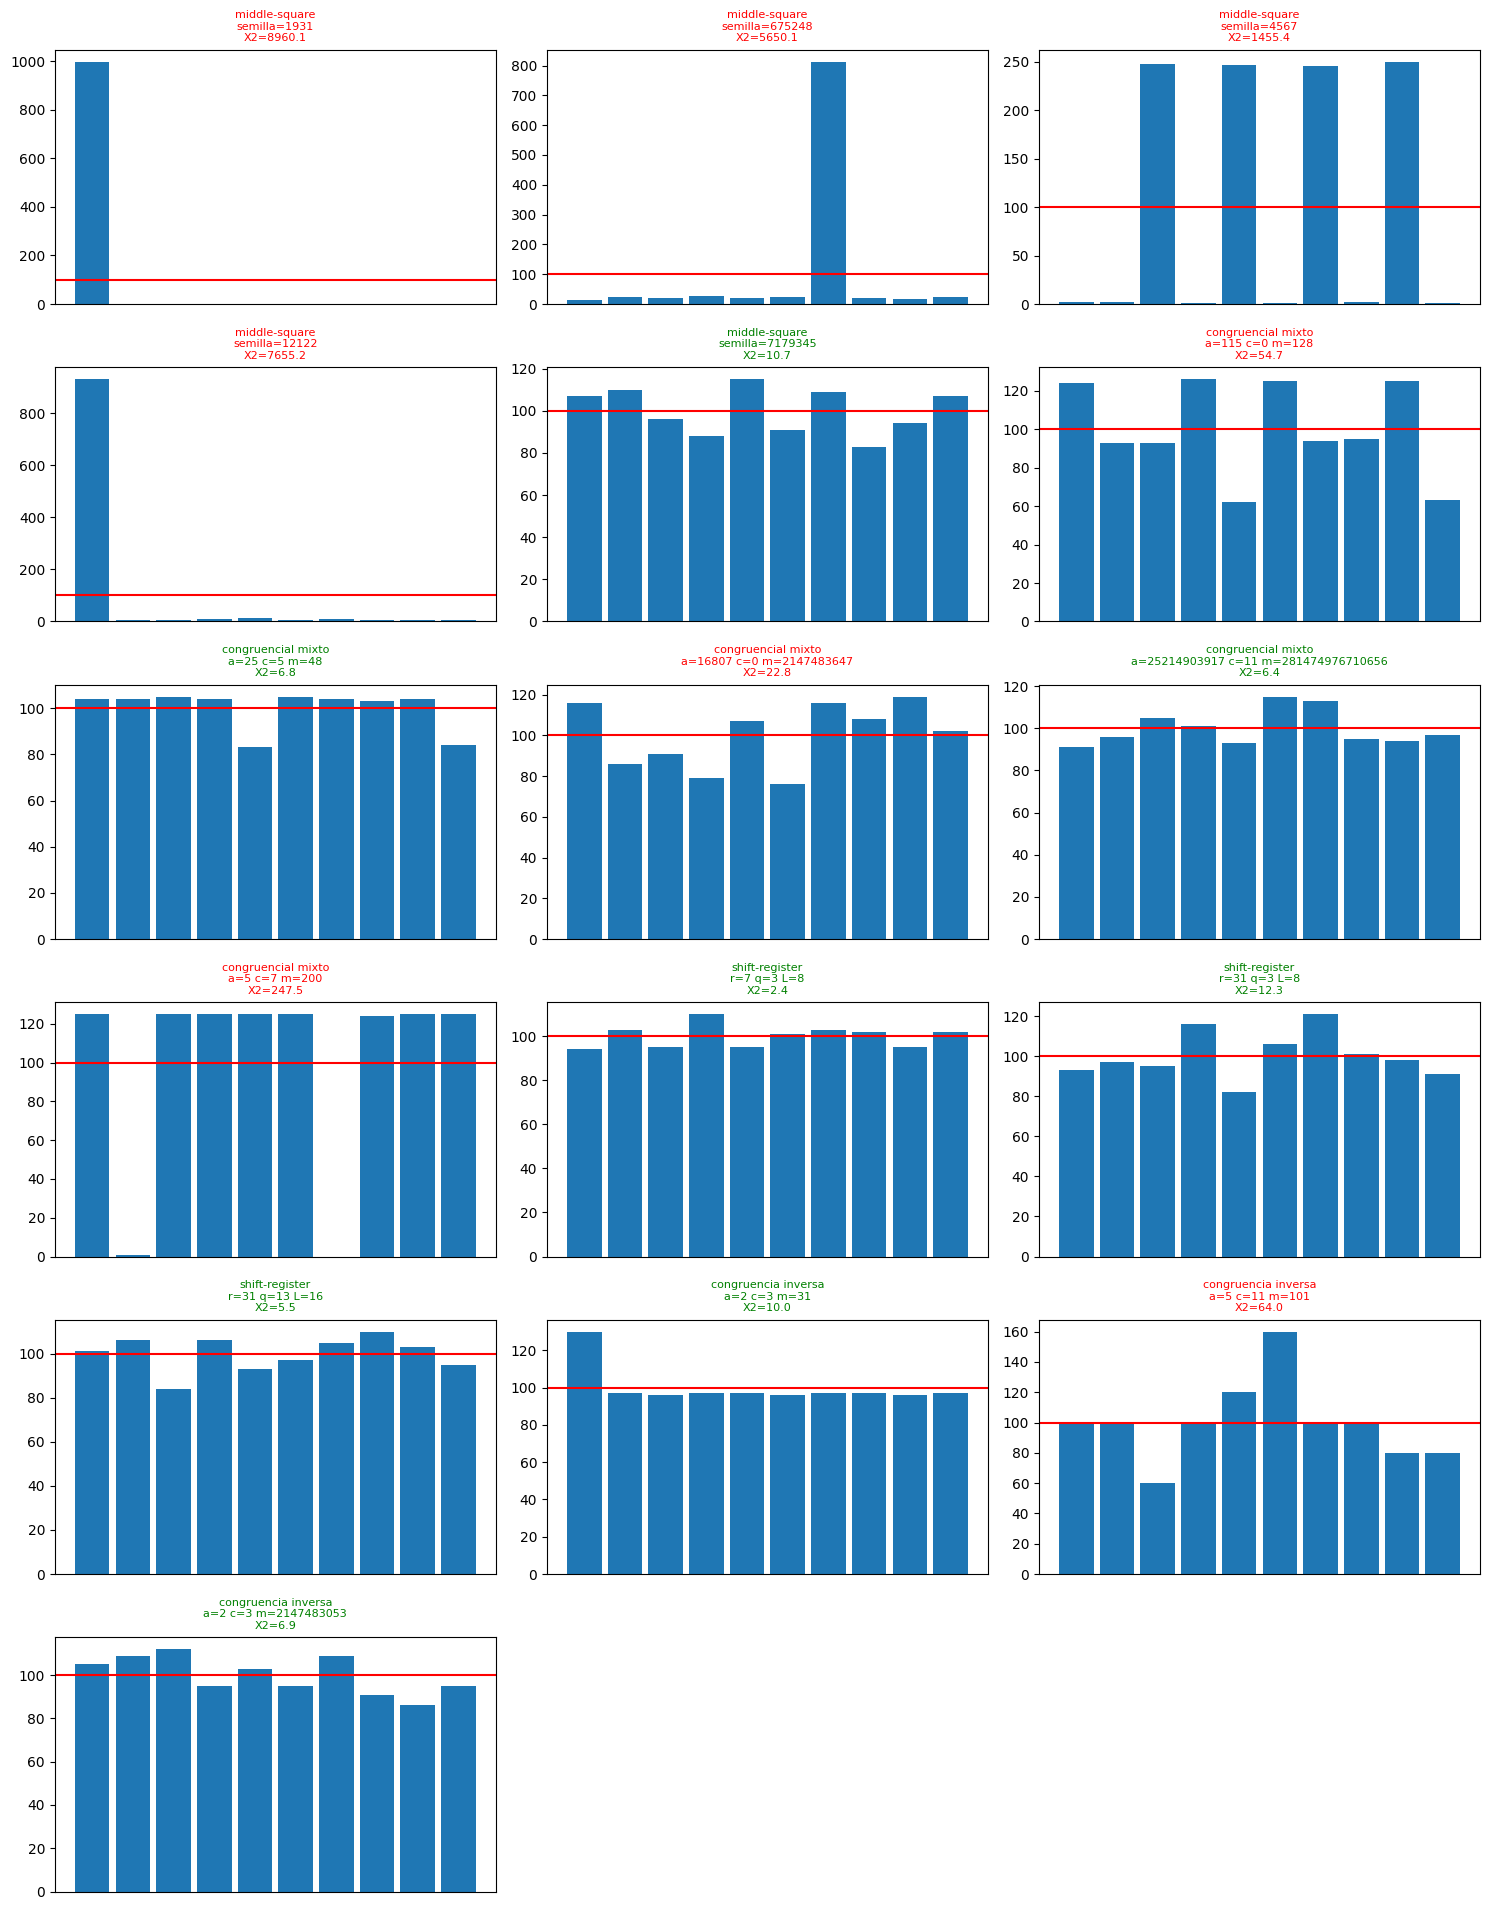

In [11]:
total = len(resultados)
columnas = 3
filas_grafico = (total + columnas - 1) // columnas

figura, ejes = plt.subplots(filas_grafico, columnas, figsize=(15, 3.2 * filas_grafico))
ejes = np.array(ejes).reshape(-1)

esperado_por_clase = CANTIDAD_NUMEROS / NUMERO_CLASES

for indice, fila in enumerate(resultados):
    eje = ejes[indice]
    eje.bar(np.arange(NUMERO_CLASES), fila["chi"]["frecuencias"], width=0.85)
    eje.axhline(esperado_por_clase, color="red", linewidth=1.5)

    color_titulo = "green" if fila["chi"]["acepta"] else "red"
    eje.set_title(f"{fila['metodo']}\n{fila['nombre']}\nX2={fila['chi']['estadistico']:.1f}",
                  fontsize=8, color=color_titulo)
    eje.set_xticks([])

for sobrante in range(total, len(ejes)):
    ejes[sobrante].axis("off")

plt.tight_layout()
plt.show()


# 5.4 Analisis

*De acuerdo con el tamano de ciclo encontrado y las pruebas de uniformidad y
aleatoriedad, responda:*

## Cuales son los peores generadores y por que

El middle-square, sin discusion. De las cinco semillas, cuatro entran en ciclo. La secuencia llega a un numero que al elevarlo al cuadrado se devuelve a
si mismo, y de ahi no sale nunca: periodo 1. Con 1931 pasa a los 6 valores. Con
12122 aguanta 87, y con 675248 llega a 209 antes de caerse. El problema no es que
sea "poco aleatorio", es que **deja de generar**. Los chi-cuadrado de 5650 y 8960
contra un critico de 16.92 son la forma matematica de decir que el histograma es
una sola barra.

La unica semilla que sobrevivio fue 7179345, y paso las dos pruebas. Eso me parece
mas peligroso que tranquilizador: si el comportamiento depende de que uno le atine
a la semilla, eso no es un generador, es una loteria.

Despues vienen dos congruenciales mal parametrizados:

- `a=5, c=7, m=200`: periodo 8. Ocho valores utiles de 200 posibles.
  $m = 2^3 \cdot 5^2$ y $a-1 = 4$ no es divisible por 5, asi que Hull-Dobell se
  rompe de una. Reprueba las dos pruebas.
- `a=115, c=0, m=128`: periodo 32, o sea $m/4$. Con $c=0$ ya no es mixto sino
  multiplicativo, y con modulo potencia de dos el techo del periodo es justamente
  $m/4$. Reprueba uniformidad.

Y el inverso con `m=101`: periodo 50, la mitad del modulo, y reprueba las dos.
Que el modulo sea primo es necesario pero claramente no alcanza; $a$ y $c$
tambien importan.

El patron es el mismo en todos: **el periodo quedo por debajo de la cantidad de
numeros que se pidieron**. Al pedir 1000 valores de un generador con periodo 8, lo
que sale es la misma lista repetida 125 veces.

## Cuales son los mejores generadores y por que

Los tres que pasaron uniformidad y rachas con periodos que ni alcance a medir por
fuerza bruta:

- **drand48** (`a=25214903917, c=11, m=2^48`). $\chi^2 = 6.36$, $Z = 0.425$.
  Cumple Hull-Dobell, asi que el periodo teorico es $2^{48}$, cerca de
  $2.8 \times 10^{14}$.
- **Shift-register con `r=31, q=13`**. $\chi^2 = 5.46$, $Z = 1.78$. Periodo
  $2^{31}-1$ porque $(31,13)$ corresponde a un trinomio primitivo. El de `r=7`
  tambien pasa limpio, pero con periodo 127 solo sirve para experimentar.
- **Congruencia inversa con modulo primo grande** (`m=2147483053`).
  $\chi^2 = 6.92$, $Z = -0.70$. Es el mas lento de todos por el `pow` modular,
  pero a cambio no tiene la estructura de reticulo que sufre el congruencial: al
  graficar pares consecutivos los puntos no se alinean en hiperplanos.